In [1]:
#importing necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
from catboost import CatBoostRegressor
import lightgbm as lgb
from sklearn.preprocessing import StandardScaler

from statsmodels.tsa.statespace.sarimax import SARIMAX

In [2]:
 #loading dataset
df = pd.read_csv("../Data/EstateProductivityPrediction_dataset.csv")

In [3]:
#null/missing values
df['irradiance_SW_DWN']= df['irradiance_SW_DWN'].replace(-999, np.nan)   #sentinal value
df.isnull().sum()

year                   0
month                  0
month_num              0
wet_days               6
rainfall               6
male_workforce       105
female_workforce     105
temperature_T2M        0
irradiance_SW_DWN      1
yield                 19
dtype: int64

In [4]:
#handling missing values of the rainfall and wet days column
df['rainfall']=(df.groupby('month')['rainfall'].transform(lambda x: x.fillna(x.median())))         #median because rainfall is skewed

df['wet_days']=(df.groupby('month')['wet_days'].transform(lambda x: x.fillna(x.median())))

# Month-wise MEDIAN imputation for yield-you can try out imputation by using knn, interpolation (forward and backward fill)
df['yield'] = (
    df.groupby('month')['yield']
      .transform(lambda x: x.fillna(x.median()))
)

#handling missing values in labour data
df['male_workforce']= (df.groupby('year')['male_workforce'].transform(lambda x: x.fillna(x.dropna().iloc[0])))

df['female_workforce']= (df.groupby('year')['female_workforce'].transform(lambda x: x.fillna(x.dropna().iloc[0])))

#sentinal value in shortwave irradiance
df['irradiance_SW_DWN']=(df.groupby('month')['irradiance_SW_DWN'].transform(lambda x: x.fillna(x.median())))

# Final check
df.isnull().sum()

year                 0
month                0
month_num            0
wet_days             0
rainfall             0
male_workforce       0
female_workforce     0
temperature_T2M      0
irradiance_SW_DWN    0
yield                0
dtype: int64

In [5]:
#handling correlation between male and female workforce

#creatine a total workforce column
df['total_workforce']=df['female_workforce']+df['male_workforce']

#creating female workforce as a ratio
df['female_workforceRatio']=df['female_workforce']/df['total_workforce']

df.drop(['male_workforce','female_workforce'], axis=1, inplace=True)

# Quick verification
print(df[['total_workforce', 'female_workforceRatio']].head())

   total_workforce  female_workforceRatio
0            901.0               0.560488
1            901.0               0.560488
2            901.0               0.560488
3            901.0               0.560488
4            901.0               0.560488


In [6]:
#adding lags
df = df.sort_values(['year', 'month_num']).reset_index(drop=True)
df['yield_lag_1']=df['yield'].shift(1)
df['yield_lag_2']=df['yield'].shift(2)
df['yield_lag_3']=df['yield'].shift(3)

#rainfall lag
df['rainfall_lag_1']= df['rainfall'].shift(1)

#remove rows with missing lags
df=df.dropna().reset_index(drop=True)

In [7]:
##new 15.02.2026- adding the code to show seasonality
df["sin_month"] = np.sin(2 * np.pi * df["month_num"] / 12)
df["cos_month"] = np.cos(2 * np.pi * df["month_num"] / 12)

df = df.drop(columns=["month_num"])


In [8]:
#the next dataset
df2=pd.read_csv('../Data/Estate_NDVI_Monthly_2016_2025_all_months.csv')

In [9]:
ndvi_aligned = df2['NDVI'].iloc[3:].reset_index(drop=True)
df['NDVI']=ndvi_aligned

In [10]:
#imputing the NVDI column using month wise median
month_median_ndvi = df.groupby('month')['NDVI'].median()

#handling outliers in NDVI
df.loc[df['NDVI'] < 0.2, 'NDVI'] = \
    df.loc[df['NDVI'] < 0.2, 'month'].map(month_median_ndvi)

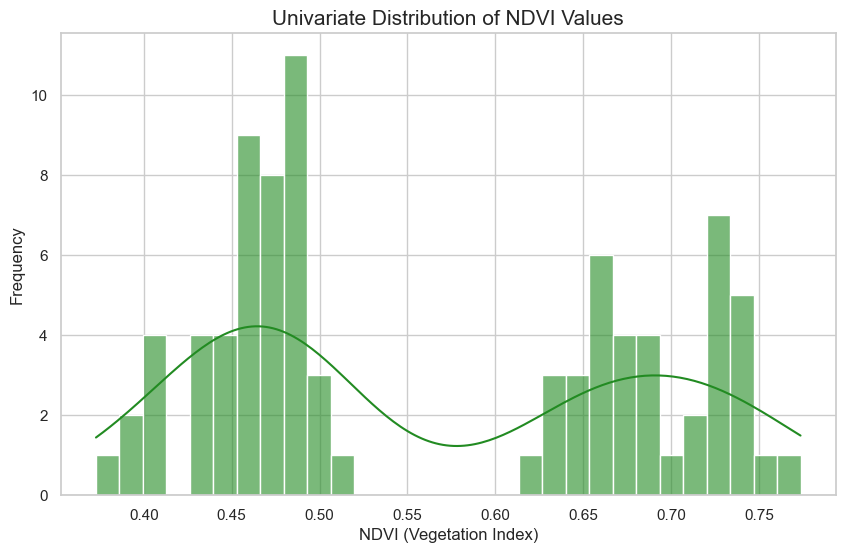

In [11]:
# Set the visual style
sns.set_theme(style="whitegrid")

# Create the plot
plt.figure(figsize=(10, 6))
sns.histplot(df['NDVI'], kde=True, color='forestgreen', bins=30, alpha=0.6)

# Formatting for clarity
plt.title('Univariate Distribution of NDVI Values', fontsize=15)
plt.xlabel('NDVI (Vegetation Index)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

# Show plot
plt.show()

In [12]:
#imputing the NVDI column using month wise median
month_median_ndvi = df.groupby('month')['NDVI'].median()

#handling outliers in NDVI
df.loc[df['NDVI'] < 0.2, 'NDVI'] = \
    df.loc[df['NDVI'] < 0.2, 'month'].map(month_median_ndvi)

#filling missing values using median
df['NDVI'] = df.apply(lambda row:month_median_ndvi[row['month']] if pd.isna(row['NDVI']) else row['NDVI'],axis=1)

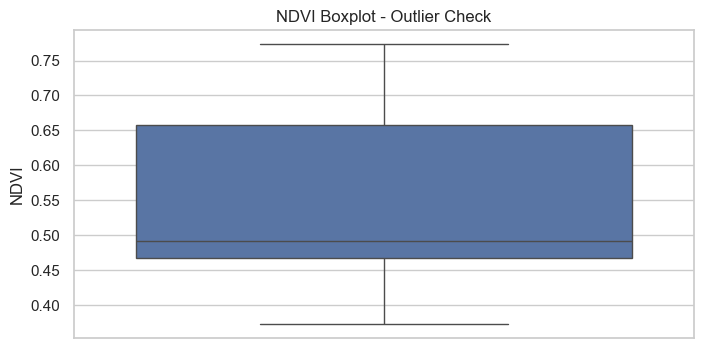

In [13]:
plt.figure(figsize=(8,4))
sns.boxplot(y=df['NDVI'])
plt.title("NDVI Boxplot - Outlier Check")
plt.show()

In [14]:
#adding rolling averages
df['NDVI_roll_3'] = df['NDVI'].rolling(window=3).mean()
#remove rows with missing lags
df=df.dropna().reset_index(drop=True)

In [15]:
df3 = pd.read_csv('../Data/Estate_EVI_Monthly_2016_2025_Scaled.csv')

In [16]:
evi_aligned = df3['EVI'].iloc[3:].reset_index(drop=True)
df['EVI']=evi_aligned

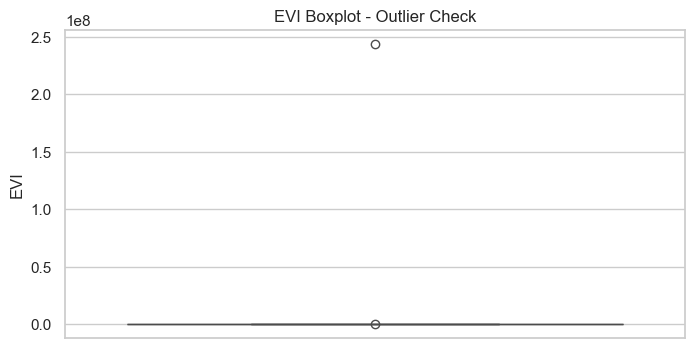

In [17]:
#newwwwwwwwwwwwwwwwwwwwwwwwwwwwwwwww
plt.figure(figsize=(8, 4))
sns.boxplot(y=df['EVI'])
plt.title("EVI Boxplot - Outlier Check")
plt.show()

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110 entries, 0 to 109
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   year                   110 non-null    int64  
 1   month                  110 non-null    object 
 2   wet_days               110 non-null    float64
 3   rainfall               110 non-null    float64
 4   temperature_T2M        110 non-null    float64
 5   irradiance_SW_DWN      110 non-null    float64
 6   yield                  110 non-null    float64
 7   total_workforce        110 non-null    float64
 8   female_workforceRatio  110 non-null    float64
 9   yield_lag_1            110 non-null    float64
 10  yield_lag_2            110 non-null    float64
 11  yield_lag_3            110 non-null    float64
 12  rainfall_lag_1         110 non-null    float64
 13  sin_month              110 non-null    float64
 14  cos_month              110 non-null    float64
 15  NDVI  

In [19]:
# Calculate Q1 and Q3
Q1 = df['EVI'].quantile(0.25)
Q3 = df['EVI'].quantile(0.75)

# Interquartile range
IQR = Q3 - Q1

# Define outliers using the boxplot rule (1.5 * IQR)
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter rows that are outliers
evi_outliers = df[(df['EVI'] < lower_bound) | (df['EVI'] > upper_bound)]

# Print outlier rows
print(evi_outliers)

    year      month  wet_days  rainfall  temperature_T2M  irradiance_SW_DWN  \
24  2018  September      13.0     275.0            22.83             5.6302   
49  2020    October      15.0     593.0            22.80             5.3143   

      yield  total_workforce  female_workforceRatio  yield_lag_1  yield_lag_2  \
24  39000.0            790.0               0.562025      26498.0      23203.0   
49  29915.0            684.0               0.564327      28343.0      25047.0   

    yield_lag_3  rainfall_lag_1  sin_month     cos_month      NDVI  \
24      38362.0          1055.0  -1.000000 -1.836970e-16  0.512142   
49      48306.0           682.0  -0.866025  5.000000e-01  0.641224   

    NDVI_roll_3           EVI  
24     0.499249  2.395596e-01  
49     0.679781  2.440000e+08  


In [20]:
df.loc[df['EVI'] > 10 , 'EVI'] = np.nan

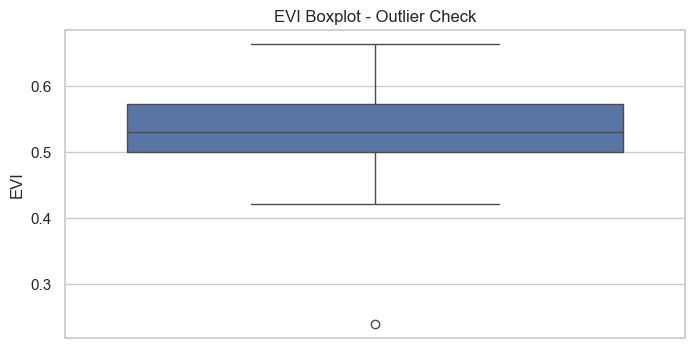

In [21]:
plt.figure(figsize=(8, 4))
sns.boxplot(y=df['EVI'])
plt.title("EVI Boxplot - Outlier Check")
plt.show()

In [22]:
# Calculate Q1 and Q3
Q1 = df['EVI'].quantile(0.25)
Q3 = df['EVI'].quantile(0.75)

# Interquartile range
IQR = Q3 - Q1

# Define outliers using the boxplot rule (1.5 * IQR)
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter rows that are outliers
evi_outliers = df[(df['EVI'] < lower_bound) | (df['EVI'] > upper_bound)]

# Print outlier rows
print(evi_outliers)

    year      month  wet_days  rainfall  temperature_T2M  irradiance_SW_DWN  \
24  2018  September      13.0     275.0            22.83             5.6302   

      yield  total_workforce  female_workforceRatio  yield_lag_1  yield_lag_2  \
24  39000.0            790.0               0.562025      26498.0      23203.0   

    yield_lag_3  rainfall_lag_1  sin_month     cos_month      NDVI  \
24      38362.0          1055.0       -1.0 -1.836970e-16  0.512142   

    NDVI_roll_3      EVI  
24     0.499249  0.23956  


In [23]:
df.loc[(df['EVI'] < lower_bound) | (df['EVI'] > upper_bound), 'EVI'] = np.nan

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110 entries, 0 to 109
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   year                   110 non-null    int64  
 1   month                  110 non-null    object 
 2   wet_days               110 non-null    float64
 3   rainfall               110 non-null    float64
 4   temperature_T2M        110 non-null    float64
 5   irradiance_SW_DWN      110 non-null    float64
 6   yield                  110 non-null    float64
 7   total_workforce        110 non-null    float64
 8   female_workforceRatio  110 non-null    float64
 9   yield_lag_1            110 non-null    float64
 10  yield_lag_2            110 non-null    float64
 11  yield_lag_3            110 non-null    float64
 12  rainfall_lag_1         110 non-null    float64
 13  sin_month              110 non-null    float64
 14  cos_month              110 non-null    float64
 15  NDVI  

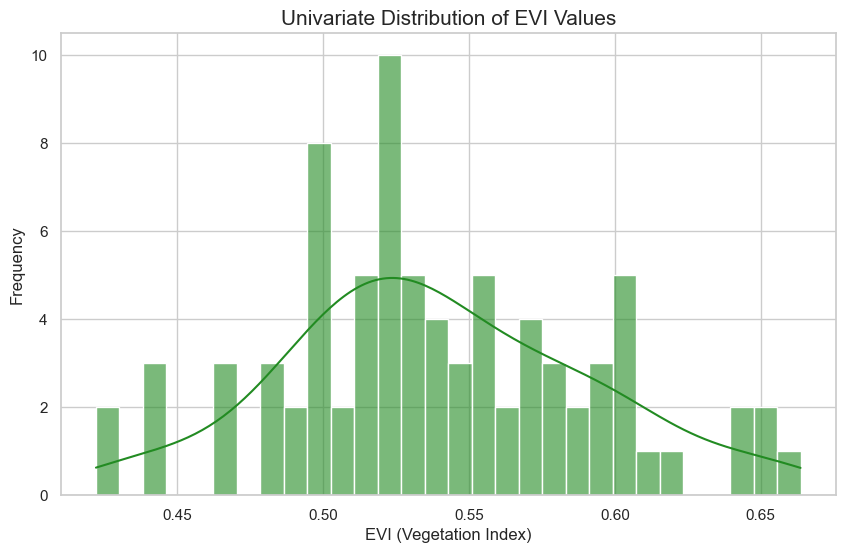

In [25]:
# Set the visual style
sns.set_theme(style="whitegrid")

# Create the plot
plt.figure(figsize=(10, 6))
sns.histplot(df['EVI'], kde=True, color='forestgreen', bins=30, alpha=0.6)

# Formatting for clarity
plt.title('Univariate Distribution of EVI Values', fontsize=15)
plt.xlabel('EVI (Vegetation Index)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

# Show plot
plt.show()

In [26]:
#imputing the EVI column using month wise median
month_median_evi = df.groupby('month')['EVI'].median()

#filling missing values using median
df['EVI'] = df.apply(lambda row:month_median_evi[row['month']] if pd.isna(row['EVI']) else row['EVI'],axis=1)

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110 entries, 0 to 109
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   year                   110 non-null    int64  
 1   month                  110 non-null    object 
 2   wet_days               110 non-null    float64
 3   rainfall               110 non-null    float64
 4   temperature_T2M        110 non-null    float64
 5   irradiance_SW_DWN      110 non-null    float64
 6   yield                  110 non-null    float64
 7   total_workforce        110 non-null    float64
 8   female_workforceRatio  110 non-null    float64
 9   yield_lag_1            110 non-null    float64
 10  yield_lag_2            110 non-null    float64
 11  yield_lag_3            110 non-null    float64
 12  rainfall_lag_1         110 non-null    float64
 13  sin_month              110 non-null    float64
 14  cos_month              110 non-null    float64
 15  NDVI  

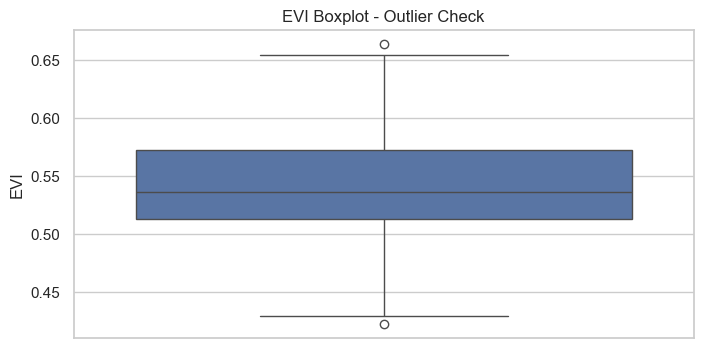

In [28]:
#no need to handle this ryt
plt.figure(figsize=(8, 4))
sns.boxplot(y=df['EVI'])
plt.title("EVI Boxplot - Outlier Check")
plt.show()

In [29]:
features = ['rainfall','wet_days','total_workforce','female_workforceRatio','yield_lag_1','yield_lag_2','yield_lag_3','rainfall_lag_1','irradiance_SW_DWN','sin_month','cos_month','NDVI','EVI','NDVI_roll_3']    #added sin_month and cos_month to features-15.02.2026

target = ['yield']
X=df[features]
Y=df[target]

In [30]:
split_idx=int(len(df)*0.8)
x_train = X.iloc[:split_idx]
y_train = Y.iloc[:split_idx]

x_test = X.iloc[split_idx:]
y_test = Y.iloc[split_idx:]


In [31]:
#initializing scaler
scaler = StandardScaler()
#scaling training data
x_train_scaled = scaler.fit_transform(x_train)
#scaling testing data
x_test_scaled = scaler.transform(x_test)

In [32]:
# Convert back to DataFrame (optional but clean)
X_train_scaled = pd.DataFrame(x_train_scaled, columns=features, index=x_train.index)
X_test_scaled = pd.DataFrame(x_test_scaled, columns=features, index=x_test.index)

In [33]:
#adding a scalar for y (yield)
# Initialize a separate scaler for the target
scaler_y = StandardScaler()

# StandardScaler expects 2D input, so we use .values.reshape(-1, 1)
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).flatten()
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1)).flatten()


In [34]:
#catboost model
cat_model = CatBoostRegressor(iterations = 1000,
                              learning_rate = 0.05,
                              depth = 6,
                              loss_function = 'RMSE',
                              eval_metric = 'RMSE',
                              random_seed = 42,
                              verbose = 100)

#fit model
cat_model.fit(x_train_scaled, y_train_scaled, eval_set = (x_test_scaled, y_test_scaled),early_stopping_rounds = 50)

0:	learn: 0.9858920	test: 0.8597373	best: 0.8597373 (0)	total: 153ms	remaining: 2m 32s
100:	learn: 0.3472056	test: 0.7318964	best: 0.7315469 (99)	total: 240ms	remaining: 2.14s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.7315469168
bestIteration = 99

Shrink model to first 100 iterations.


In [35]:
y_pred_cat_scaled = cat_model.predict(x_test_scaled)

In [36]:
# Convert back to original units (e.g., kg/hectare)
y_pred_cat = scaler_y.inverse_transform(y_pred_cat_scaled.reshape(-1, 1)).flatten()

In [37]:
mse = mean_squared_error(y_test, y_pred_cat)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred_cat)
r2 = r2_score(y_test, y_pred_cat)

print("CatBoost Yield Prediction Performance")
print(f"RMSE: {rmse:.2f}")
print(f"MAE : {mae:.2f}")
print(f"R²  : {r2:.3f}")


CatBoost Yield Prediction Performance
RMSE: 10234.03
MAE : 8601.10
R²  : -0.124


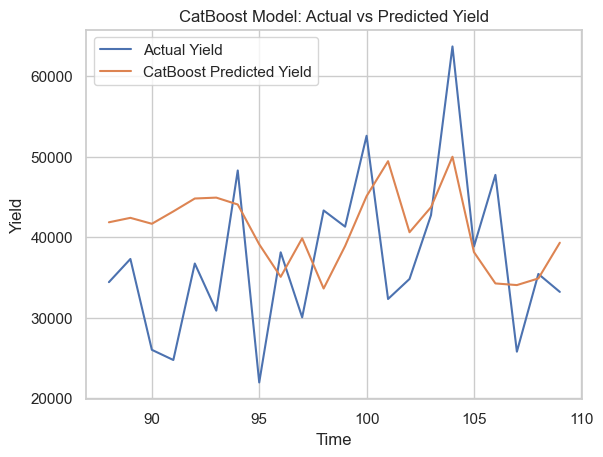

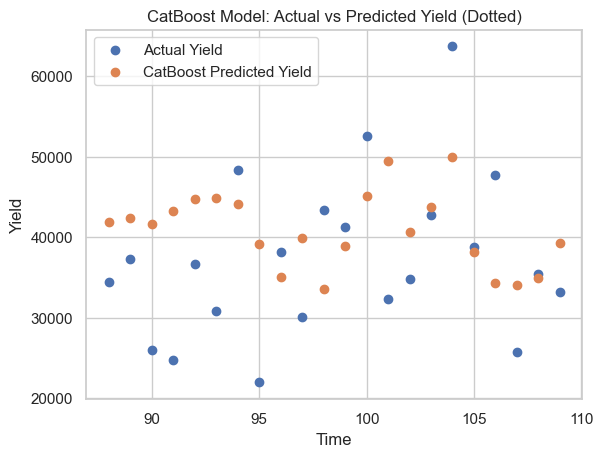

In [38]:
#line plot
plt.figure()

plt.plot(y_test.index, y_test.values, label="Actual Yield")
plt.plot(y_test.index, y_pred_cat, label="CatBoost Predicted Yield")

plt.legend()
plt.title("CatBoost Model: Actual vs Predicted Yield")
plt.xlabel("Time")
plt.ylabel("Yield")

plt.show()

#scatter plot
plt.figure()

plt.scatter(y_test.index, y_test.values,
            label="Actual Yield")

plt.scatter(y_test.index, y_pred_cat,
            label="CatBoost Predicted Yield")

plt.legend()
plt.title("CatBoost Model: Actual vs Predicted Yield (Dotted)")
plt.xlabel("Time")
plt.ylabel("Yield")

plt.show()

In [39]:
#XGBoost on the dataset with ndvi
xgb_model = XGBRegressor(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42
)

xgb_model.fit(x_train_scaled, y_train_scaled)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [40]:
# --- 2. PREDICT & UN-SCALE ---
# The model outputs scaled predictions (small decimals)
y_pred_xgb_scaled = xgb_model.predict(x_test_scaled)

# Convert predictions back to original Yield units (kg/hectare)
y_pred_xgb = scaler_y.inverse_transform(y_pred_xgb_scaled.reshape(-1, 1)).flatten()

In [41]:
#y_pred_xgb = xgb_model.predict(x_test_scaled)

rmse = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
mae  = mean_absolute_error(y_test, y_pred_xgb)
r2   = r2_score(y_test, y_pred_xgb)

print("Model A — XGBoost Yield Prediction")
print(f"RMSE: {rmse:.2f}")
print(f"MAE : {mae:.2f}")
print(f"R²  : {r2:.3f}")

Model A — XGBoost Yield Prediction
RMSE: 9811.11
MAE : 8218.85
R²  : -0.033


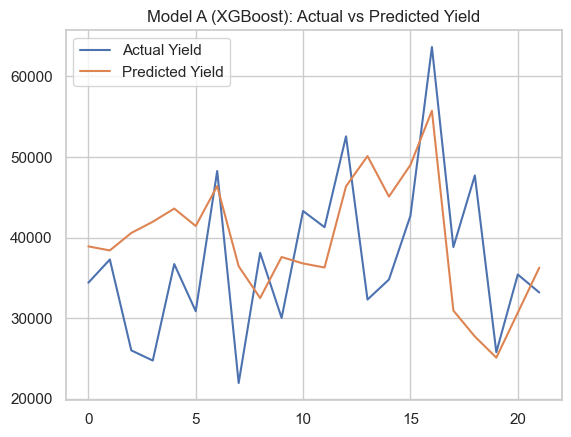

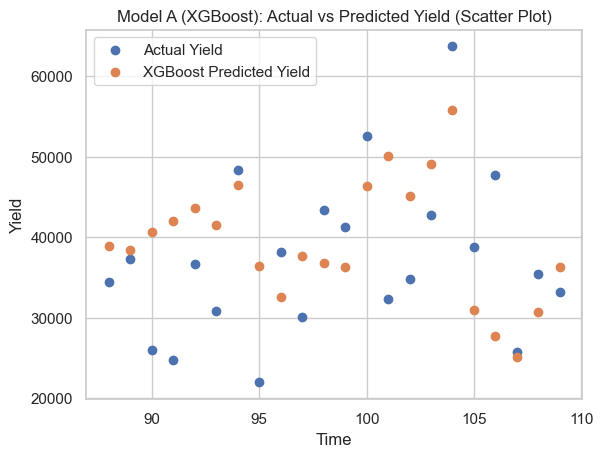

In [42]:
plt.figure()
plt.plot(y_test.values, label="Actual Yield")
plt.plot(y_pred_xgb, label="Predicted Yield")
plt.legend()
plt.title("Model A (XGBoost): Actual vs Predicted Yield")
plt.show()

plt.figure()

#scatter plot
plt.scatter(y_test.index, y_test.values, label="Actual Yield")
plt.scatter(y_test.index, y_pred_xgb, label="XGBoost Predicted Yield")
plt.legend()
plt.title("Model A (XGBoost): Actual vs Predicted Yield (Scatter Plot)")
plt.xlabel("Time")
plt.ylabel("Yield")
plt.show()



In [43]:
#trying a basic ensemble method with xgboost and catboost
y_pred_avg = (y_pred_xgb+y_pred_cat)/2

mse = mean_squared_error(y_test, y_pred_avg)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred_avg)
r2 = r2_score(y_test, y_pred_avg)

print("Ensemble (XGBoost + CatBoost) Performance")
print(f"RMSE: {rmse:.2f}")
print(f"MAE : {mae:.2f}")
print(f"R²  : {r2:.3f}")

Ensemble (XGBoost + CatBoost) Performance
RMSE: 9815.07
MAE : 8379.52
R²  : -0.034


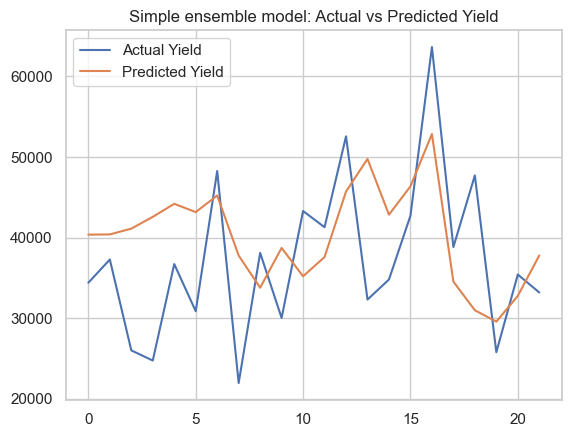

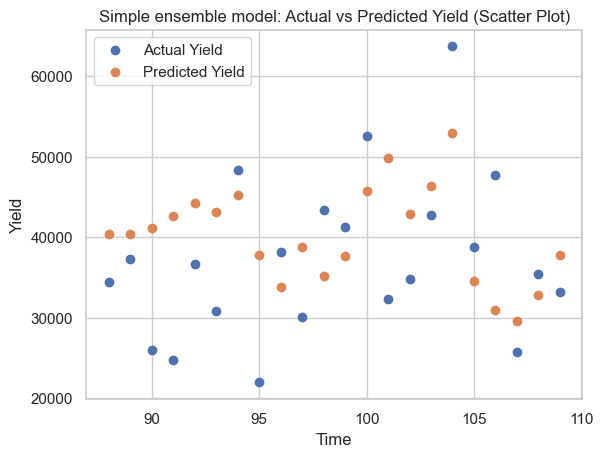

In [44]:
plt.figure()
plt.plot(y_test.values, label="Actual Yield")
plt.plot(y_pred_avg, label="Predicted Yield")
plt.legend()
plt.title("Simple ensemble model: Actual vs Predicted Yield")
plt.show()

plt.figure()

#scatter plot
plt.scatter(y_test.index, y_test.values, label="Actual Yield")
plt.scatter(y_test.index, y_pred_avg, label="Predicted Yield")
plt.legend()
plt.title("Simple ensemble model: Actual vs Predicted Yield (Scatter Plot)")
plt.xlabel("Time")
plt.ylabel("Yield")
plt.show()